# Деревья решений и ансамблевые методы

Датасет: [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package) (`weatherAUS.csv`) — ежедневные наблюдения за погодой на метеостанциях Австралии. Целевая переменная: `RainTomorrow` (будет ли дождь на следующий день).

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "weatherAUS.csv"

# Load the latest version of the dataset
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "jsphyg/weather-dataset-rattle-package",
    file_path,
)

print("Первые 5 записей: \n", df.head())

Первые 5 записей: 
          Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
# Categorical slots in fixed order; INK for reference lines
BLUE, ORANGE, AQUA, INK = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

## Размерность и типы колонок

Проверяем объём данных и какие признаки числовые, а какие категориальные — от этого зависит предобработка.


In [3]:
df.shape, df.dtypes

((145460, 23),
 Date                 str
 Location             str
 MinTemp          float64
 MaxTemp          float64
 Rainfall         float64
 Evaporation      float64
 Sunshine         float64
 WindGustDir          str
 WindGustSpeed    float64
 WindDir9am           str
 WindDir3pm           str
 WindSpeed9am     float64
 WindSpeed3pm     float64
 Humidity9am      float64
 Humidity3pm      float64
 Pressure9am      float64
 Pressure3pm      float64
 Cloud9am         float64
 Cloud3pm         float64
 Temp9am          float64
 Temp3pm          float64
 RainToday            str
 RainTomorrow         str
 dtype: object)

## Распределение целевой переменной

Смотрим баланс классов `RainTomorrow`: сильный перекос (дождь — редкое событие) потребует учёта при обучении и оценке качества.


In [4]:
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

Слева — баланс классов: дождливых дней примерно в 3.5 раза меньше. Справа — сезонность: зимой (июнь–август) дождь идёт чаще, поэтому validation и test должны покрывать полный год, иначе оценка будет смещена.

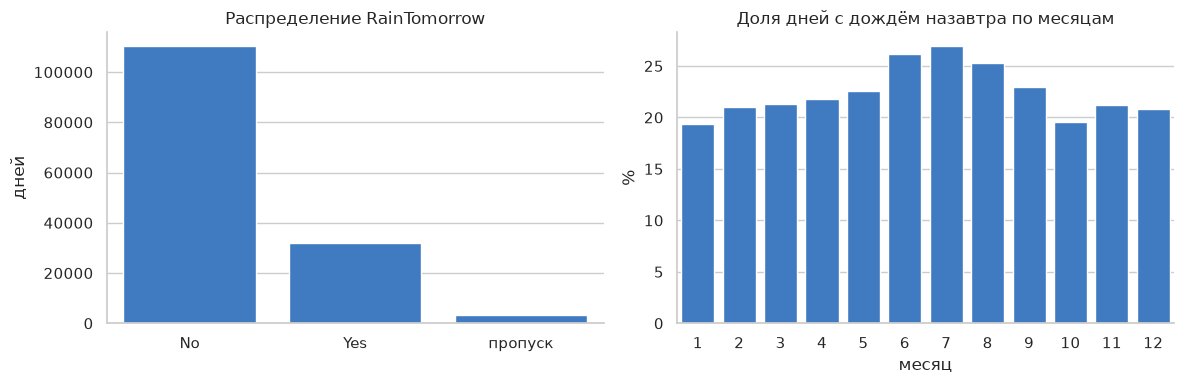

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df["RainTomorrow"].fillna("пропуск"), order=["No", "Yes", "пропуск"],
              color=BLUE, ax=axes[0])
axes[0].set(title="Распределение RainTomorrow", xlabel="", ylabel="дней")

labeled = df.dropna(subset=["RainTomorrow"])
rain_by_month = (labeled["RainTomorrow"] == "Yes").groupby(
    pd.to_datetime(labeled["Date"]).dt.month).mean().mul(100)
sns.barplot(x=rain_by_month.index, y=rain_by_month.values, color=BLUE, ax=axes[1])
axes[1].set(title="Доля дней с дождём назавтра по месяцам", xlabel="месяц", ylabel="%")

plt.tight_layout()
plt.show()

## Разбиение данных: только по времени

Это временной ряд: одни и те же станции наблюдаются день за днём, а соседние дни почти неотличимы. Случайное перемешивание строк перед разбиением приводит к утечке (leakage):

- завтрашний день попадает в test, а сегодняшний (практически такой же) — в train, поэтому метрики завышены;
- сезонность распределяется по train и test равномерно, хотя в реальности модель прогнозирует будущее по прошлому.

Поэтому split делаем хронологический: train — ранние годы, validation — следующие, test — самые поздние. Модель всегда учится на прошлом и проверяется на будущем.


## Метрики качества

Классы сильно несбалансированы: дождь — редкое событие (~22% дней). Константный прогноз «Нет» получит accuracy ≈ 0.78, ничего не предсказывая, поэтому accuracy сама по себе неинформативна. Используем:

- **Precision** — доля верных среди предсказанных дождей: цена ложной тревоги;
- **Recall** — доля пойманных реальных дождей: цена пропуска;
- **PR-AUC** — сводка пар precision/recall по всем порогам; при сильном дисбалансе показательнее ROC-AUC;
- **ROC-AUC** — ранжирующая способность модели, не зависит от порога, но при дисбалансе бывает оптимистичной;
- **Калибровка** — правдивость вероятностей: если модель говорит «70% дождя», дождь должен идти примерно в 70% таких дней (calibration curve).

Порог классификации подбирается на validation под нужный баланс precision/recall, а не берётся по умолчанию 0.5.

Дисбаланс учитываем именно порогом, а не весами классов. `class_weight="balanced"` считает каждый дождливый день примерно за 3.5 и завышает все вероятности: «56% дождя» на деле означало 26%. На ранжирование веса не влияют (PR-AUC тот же), а сдвиг вероятностей порог и так компенсирует. Без весов вероятности остаются откалиброванными, и их можно читать как реальные шансы дождя.


## Проектирование признаков

План предобработки (по Буркову, гл. 5.1, применительно к этому датасету):

**Утечки.** Сырую `Date` убираем, но извлекаем из неё `month` и `day_of_year` — сезонность сильный сигнал о дожде.

**Категориальные признаки.** `WindGustDir`, `WindDir9am`, `WindDir3pm`, `Location` — без естественного порядка, поэтому one-hot кодирование. `RainToday`, `RainTomorrow` — бинарные, переводим в 0/1.

**Биннинг — не применяем.** Дискретизация непрерывных признаков полезна линейным моделям, а дерево решений само строит пороги.

**Масштабирование — не применяем.** Нормализация и стандартизация нужны градиентному спуску; дерево разбивает по порогам и к масштабу нечувствительно.

**Пропуски.** В `Sunshine`, `Evaporation`, `Cloud3pm` пропусков до ~48%. Стратегия — комбинация двух приёмов:
- бинарный признак-индикатор «значение отсутствовало» — сам факт отсутствия измерения информативен (мелкая станция);
- заполнение медианой для числовых, модой для категориальных.

Альтернатива — нативная поддержка `NaN` в `DecisionTreeClassifier`/`HistGradientBoostingClassifier` (scikit-learn ≥ 1.3); апгрейд — регрессионная импутация (`IterativeImputer`). Стратегия фитится только на train внутри `Pipeline` и та же применяется на validation/test и при прогнозе.

**Почему именно медиана и мода.** Среднее чувствительно к скошенным распределениям: в `Rainfall` большинство дней нулевые, но бывают ливни > 100 мм, и среднее (~2.4 мм) — значение, которое почти не встречается. Медиана задаёт «типичный» день и устойчива к хвостам. Мода для категорий — самое частое значение, но она раздувает доминирующую категорию; для `WindDir*` часто честнее завести явную категорию `"Missing"` — дерево само решит, как её использовать.

**Зачем индикаторы.** Заполнение одной константой смешивает два разных случая — «реальная погода» и «измерения не было» — и занижает разброс признака. Индикатор `colname_missing` (`SimpleImputer(add_indicator=True)`) отделяет их: пропуск неслучаен (нет оборудования = мелкая станция), и сам факт отсутствия — сигнал для модели. На прогнозе используется та же статистика, вычисленная на train.


Доля пропусков по колонкам: у `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am` их от 38 до 48% — отсюда индикаторы пропуска.

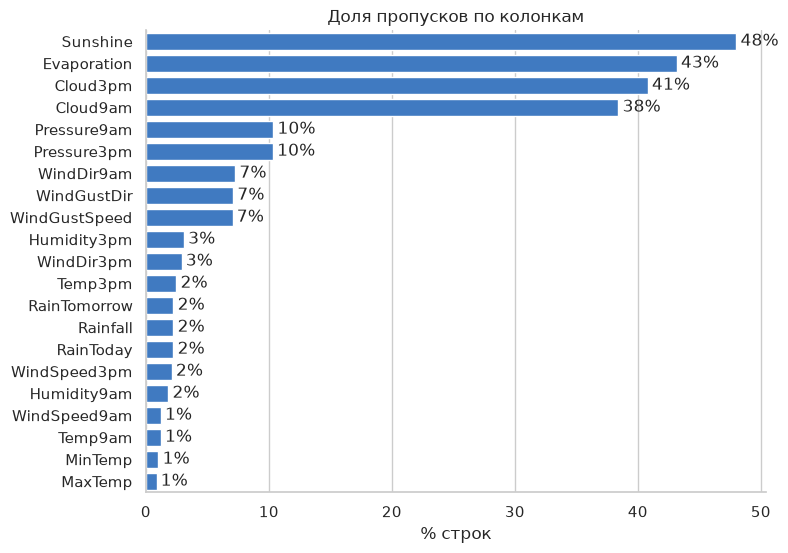

In [6]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=missing.values, y=missing.index, color=BLUE, ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3)
ax.set(title="Доля пропусков по колонкам", xlabel="% строк", ylabel="")
plt.show()

## Разбиение

Сплит делаем по времени **до** любых статистик препроцессинга. Данные заканчиваются 2017-06-25, поэтому граница проходит по середине года: train — до 2015-06-30, validation — 2015-07 … 2016-06, test — 2016-07 … 2017-06. Так validation и test охватывают ровно по году и включают все сезоны, в том числе дождливую зиму (июнь–август); тест только за январь–июнь 2017 давал бы оценку на половине года. Строки без `RainTomorrow` удаляем; из `Date` достаём `month` и `day_of_year`.

In [7]:
import pandas as pd
# Prepare the dataframe: drop unlabeled rows, add date features
df = df[df["RainTomorrow"].notna()].copy()
df["Date"] = pd.to_datetime(df["Date"])
df["month"] = df["Date"].dt.month
df["day_of_year"] = df["Date"].dt.dayofyear
df["RainToday"] = (df["RainToday"] == "Yes").astype(int)

y = (df["RainTomorrow"] == "Yes").astype(int)
X = df.drop(columns=["Date", "RainTomorrow"])

# Chronological split: train on the past, validate and test on the future.
# Data ends 2017-06-25, so val and test are full mid-year-to-mid-year windows
train_mask = df["Date"] <= "2015-06-30"
val_mask = (df["Date"] >= "2015-07-01") & (df["Date"] <= "2016-06-30")
test_mask = df["Date"] >= "2016-07-01"

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

for name, d in [("train", df[train_mask]), ("val", df[val_mask]), ("test", df[test_mask])]:
    print(f"{name:5} {d['Date'].min().date()} … {d['Date'].max().date()}  "
          f"{d.shape[0]:6} строк, доля дождя: {100 * (d['RainTomorrow'] == 'Yes').mean():.1f}%")

train 2007-11-01 … 2015-06-30  107502 строк, доля дождя: 22.5%
val   2015-07-01 … 2016-06-30   17405 строк, доля дождя: 21.2%
test  2016-07-01 … 2017-06-25   17286 строк, доля дождя: 23.2%


Помесячная доля дождливых дней и границы разбиения: каждая часть строго позже предыдущей, validation и test — по полному году.

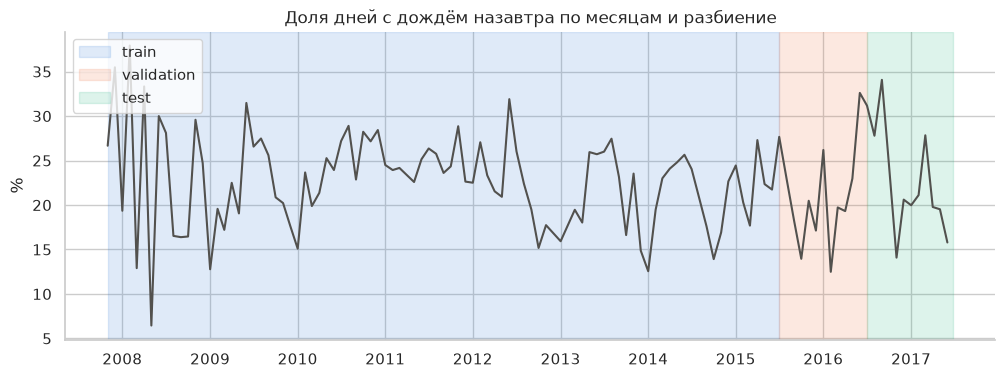

In [8]:
rain_by_period = y.groupby(df["Date"].dt.to_period("M").dt.to_timestamp()).mean().mul(100)

fig, ax = plt.subplots(figsize=(12, 4))
spans = [
    ("train", df["Date"].min(), "2015-06-30", BLUE),
    ("validation", "2015-07-01", "2016-06-30", ORANGE),
    ("test", "2016-07-01", df["Date"].max(), AQUA),
]
for name, start, end, color in spans:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=0.15, label=name)
sns.lineplot(x=rain_by_period.index, y=rain_by_period.values, color=INK, linewidth=1.5, ax=ax)
ax.set(title="Доля дней с дождём назавтра по месяцам и разбиение", xlabel="", ylabel="%")
ax.legend(loc="upper left")
plt.show()

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

num_cols = [
    "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm",
    "RainToday", "month", "day_of_year",
]
cat_cols = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"]

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", add_indicator=True), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

# Fit only on train
X_train_t = preprocess.fit_transform(X_train)

names = preprocess.get_feature_names_out()
print("размер после препроцессинга:", X_train_t.shape)
print("индикаторных колонок:", sum("_missing" in n for n in names))
import numpy as np
from scipy import sparse
X_dense = X_train_t.toarray() if sparse.issparse(X_train_t) else np.asarray(X_train_t)
print("NaN после трансформации:", np.isnan(X_dense).sum())

размер после препроцессинга: (107502, 135)
индикаторных колонок: 16
NaN после трансформации: 0


In [10]:
# Val/test are transformed with the statistics fitted on train — no refit
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

X_val_dense = X_val_t.toarray() if sparse.issparse(X_val_t) else np.asarray(X_val_t)
print("val:", X_val_t.shape, "NaN:", np.isnan(X_val_dense).sum())
print("test:", X_test_t.shape)

val: (17405, 135) NaN: 0
test: (17286, 135)


## Обучение базовой модели

Начнём с дерева без ограничений глубины: оно вырастет до чистых листьев и переобучится — это ожидаемо и будет видно по разрыву train/validation.

In [11]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

model = Pipeline([
    ("prep", clone(preprocess)),
    ("tree", DecisionTreeClassifier(random_state=42)),
])
model.fit(X_train, y_train)

for name, X_, y_ in [("train", X_train, y_train), ("val", X_val, y_val)]:
    proba = model.predict_proba(X_)[:, 1]
    print(f"{name}: PR-AUC = {average_precision_score(y_, proba):.3f}, "
          f"ROC-AUC = {roc_auc_score(y_, proba):.3f}")

tree = model.named_steps["tree"]
print(f"глубина: {tree.get_depth()}, листьев: {tree.get_n_leaves()}")

train: PR-AUC = 1.000, ROC-AUC = 1.000
val: PR-AUC = 0.360, ROC-AUC = 0.686
глубина: 45, листьев: 11874


## Подбор гиперпараметров

Перебираем `max_depth` и `min_samples_leaf` по PR-AUC на validation. Перебор — самая долгая часть ноутбука, поэтому результаты кэшируются на диск (`joblib.Memory`, папка `.cache/`). Ключ кэша — аргументы и исходный код функции: если меняются данные, сетка или код, перебор пересчитывается сам, иначе таблица читается с диска.

In [12]:
from itertools import product

import pandas as pd
from joblib import Memory
from tqdm.auto import tqdm

# Cached on disk, keyed by the arguments and this function's source
memory = Memory(".cache/joblib", verbose=0)


@memory.cache
def run_grid(preprocess, X_train, y_train, X_val, y_val, depths, leaves):
    rows = []
    for depth, leaf in tqdm(
        list(product(depths, leaves)),
        desc="перебор конфигураций", unit="комб.",
    ):
        m = Pipeline([
            ("prep", clone(preprocess)),
            ("tree", DecisionTreeClassifier(
                random_state=42,
                max_depth=depth, min_samples_leaf=leaf)),
        ])
        m.fit(X_train, y_train)
        rows.append({
            "max_depth": depth,
            "min_samples_leaf": leaf,
            "train_pr_auc": average_precision_score(y_train, m.predict_proba(X_train)[:, 1]),
            "val_pr_auc": average_precision_score(y_val, m.predict_proba(X_val)[:, 1]),
        })
    return pd.DataFrame(rows)


grid = run_grid(
    preprocess, X_train, y_train, X_val, y_val,
    depths=range(3, 16), leaves=[1, 5, 20, 50, 100, 200, 400],
).sort_values("val_pr_auc", ascending=False)
print("лучшие 5 конфигураций:")
print(grid.head(5).to_string(index=False))

best = grid.iloc[0]
best_depth, best_leaf = int(best.max_depth), int(best.min_samples_leaf)
print(f"\nвыбрано: max_depth={best_depth}, min_samples_leaf={best_leaf}")


лучшие 5 конфигураций:
 max_depth  min_samples_leaf  train_pr_auc  val_pr_auc
        15               200      0.709698    0.649588
        14               200      0.709459    0.649395
        13               200      0.709070    0.649090
        12               200      0.708317    0.648743
        11               200      0.706793    0.648081

выбрано: max_depth=15, min_samples_leaf=200


## Переобучение

PR-AUC на train и validation в зависимости от глубины. При `min_samples_leaf=1` train растёт с каждым уровнем, а validation после глубины ~8 падает — дерево запоминает шум. С крупными листьями обе кривые выходят на плато и глубина перестаёт вредить: ограничение размера листа и есть главный регуляризатор.

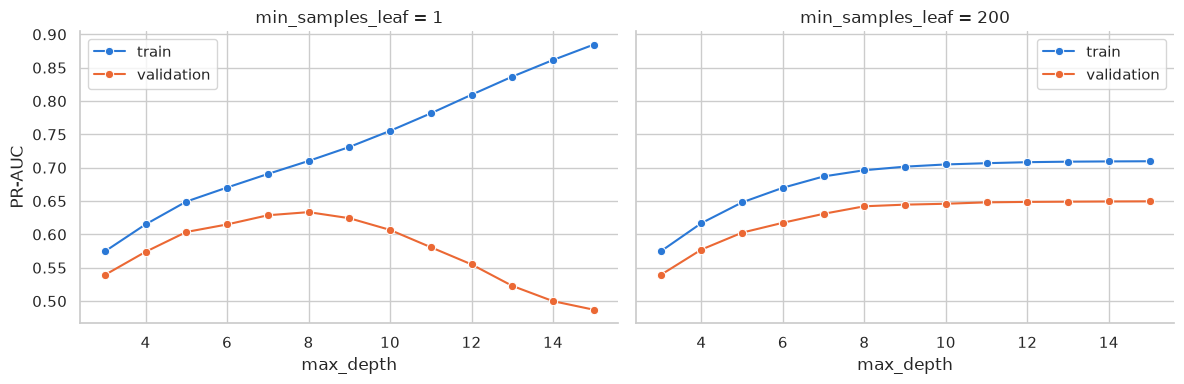

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, leaf in zip(axes, [1, best_leaf]):
    sub = grid[grid["min_samples_leaf"] == leaf].sort_values("max_depth")
    sns.lineplot(data=sub, x="max_depth", y="train_pr_auc", marker="o", color=BLUE, label="train", ax=ax)
    sns.lineplot(data=sub, x="max_depth", y="val_pr_auc", marker="o", color=ORANGE, label="validation", ax=ax)
    ax.set(title=f"min_samples_leaf = {leaf}", xlabel="max_depth", ylabel="PR-AUC")
plt.tight_layout()
plt.show()

PR-AUC на validation по всей сетке; рамкой выделена выбранная конфигурация. Видно плато: при достаточно крупных листьях глубина почти не влияет на качество.

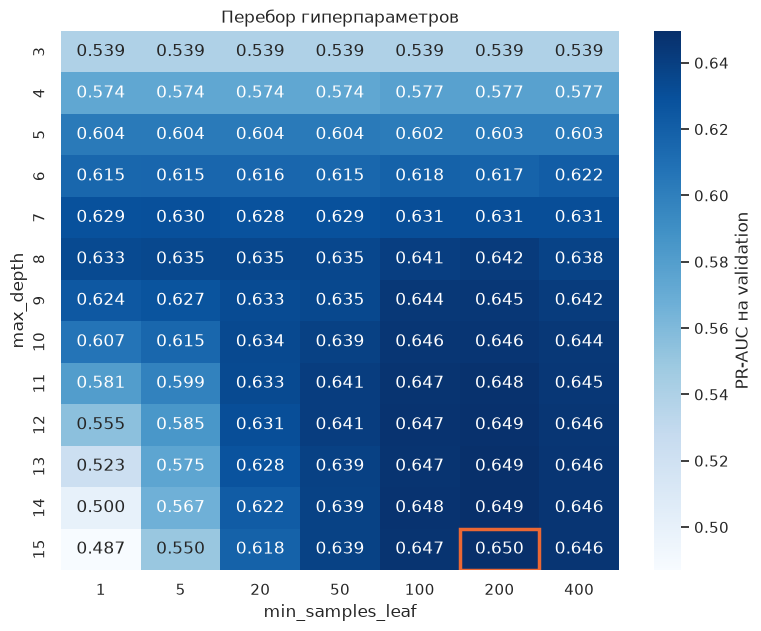

In [14]:
pivot = grid.pivot(index="max_depth", columns="min_samples_leaf", values="val_pr_auc")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues",
            cbar_kws={"label": "PR-AUC на validation"}, ax=ax)
ax.add_patch(plt.Rectangle(
    (pivot.columns.get_loc(best_leaf), pivot.index.get_loc(best_depth)), 1, 1,
    fill=False, edgecolor=ORANGE, linewidth=2.5))
ax.set(title="Перебор гиперпараметров", xlabel="min_samples_leaf", ylabel="max_depth")
plt.show()

In [15]:
from sklearn.metrics import precision_recall_curve

best_model = Pipeline([
    ("prep", clone(preprocess)),
    ("tree", DecisionTreeClassifier(
        random_state=42,
        max_depth=best_depth, min_samples_leaf=best_leaf)),
])
best_model.fit(X_train, y_train)

val_proba = best_model.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1 = 2 * prec * rec / (prec + rec)
best_i = f1.argmax()
threshold = thr[best_i]

print(f"порог по max F1 на validation: {threshold:.2f}")
print(f"precision = {prec[best_i]:.3f}, recall = {rec[best_i]:.3f}, F1 = {f1[best_i]:.3f}")

порог по max F1 на validation: 0.30
precision = 0.561, recall = 0.641, F1 = 0.598


Precision, recall и F1 в зависимости от порога на validation. Ниже порог — больше пойманных дождей, но больше ложных тревог; пунктир — выбранный порог по максимуму F1.

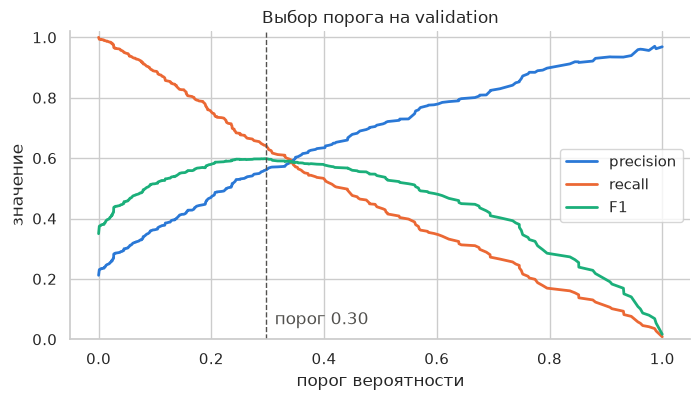

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
for values, name, color in [(prec, "precision", BLUE), (rec, "recall", ORANGE), (f1, "F1", AQUA)]:
    sns.lineplot(x=thr, y=values[:-1], label=name, color=color, linewidth=2, ax=ax)
ax.axvline(threshold, color=INK, linestyle="--", linewidth=1)
ax.annotate(f"порог {threshold:.2f}", (threshold, 0.05), xytext=(6, 0),
            textcoords="offset points", color=INK)
ax.set(title="Выбор порога на validation", xlabel="порог вероятности", ylabel="значение", ylim=(0, 1.02))
plt.show()

In [17]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
)

# Refit on train+val with fixed hyperparameters, touch test once
X_fit = pd.concat([X_train, X_val])
y_fit = pd.concat([y_train, y_val])
final = Pipeline([
    ("prep", clone(preprocess)),
    ("tree", DecisionTreeClassifier(
        random_state=42,
        max_depth=best_depth, min_samples_leaf=best_leaf)),
])
final.fit(X_fit, y_fit)

test_proba = final.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= threshold).astype(int)

print("=== TEST ===")
print(f"PR-AUC  = {average_precision_score(y_test, test_proba):.3f}")
print(f"ROC-AUC = {roc_auc_score(y_test, test_proba):.3f}")
print(f"precision = {precision_score(y_test, test_pred):.3f} @ threshold={threshold:.2f}")
print(f"recall    = {recall_score(y_test, test_pred):.3f}")
print(f"F1        = {f1_score(y_test, test_pred):.3f}")
print("confusion matrix [[TN FP], [FN TP]]:")
print(confusion_matrix(y_test, test_pred))

frac, mean_p = calibration_curve(y_test, test_proba, n_bins=8)
print("калибровка (предсказанная вероятность -> фактическая доля дождя):")
for mp, fr in zip(mean_p, frac):
    print(f"  {mp:.2f} -> {fr:.2f}")

naive_acc = (y_test == 0).mean()
print(f"наивная база (всегда Нет): accuracy = {naive_acc:.3f}")

=== TEST ===
PR-AUC  = 0.662
ROC-AUC = 0.844
precision = 0.551 @ threshold=0.30
recall    = 0.682
F1        = 0.610
confusion matrix [[TN FP], [FN TP]]:
[[11055  2225]
 [ 1272  2734]]
калибровка (предсказанная вероятность -> фактическая доля дождя):
  0.05 -> 0.06
  0.18 -> 0.19
  0.30 -> 0.30
  0.43 -> 0.44
  0.56 -> 0.52
  0.68 -> 0.65
  0.82 -> 0.84
  0.96 -> 0.93
наивная база (всегда Нет): accuracy = 0.768


## Качество на test

Матрица ошибок при выбранном пороге (в ячейках — число дней и доля от строки), кривые Precision–Recall и ROC (точка — рабочий порог) и калибровочная кривая: чем ближе к диагонали, тем честнее вероятности.

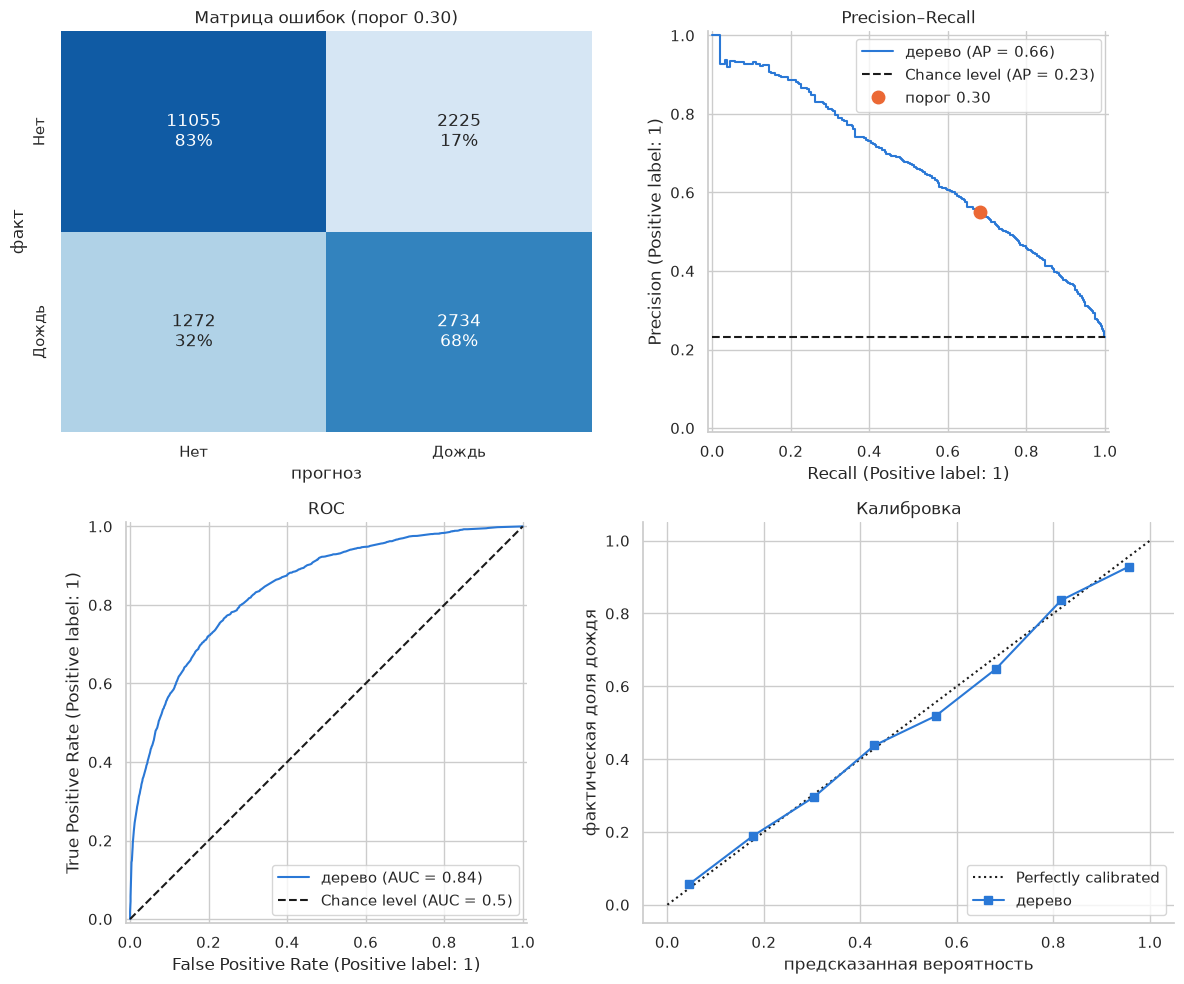

In [18]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cm = confusion_matrix(y_test, test_pred)
cm_share = cm / cm.sum(axis=1, keepdims=True)
labels = [[f"{n}\n{s:.0%}" for n, s in zip(row_n, row_s)] for row_n, row_s in zip(cm, cm_share)]
sns.heatmap(cm_share, annot=labels, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
            xticklabels=["Нет", "Дождь"], yticklabels=["Нет", "Дождь"], ax=axes[0, 0])
axes[0, 0].set(title=f"Матрица ошибок (порог {threshold:.2f})", xlabel="прогноз", ylabel="факт")

PrecisionRecallDisplay.from_predictions(
    y_test, test_proba, name="дерево", curve_kwargs={"color": BLUE},
    plot_chance_level=True, ax=axes[0, 1])
axes[0, 1].plot(recall_score(y_test, test_pred), precision_score(y_test, test_pred), "o",
                color=ORANGE, markersize=9, label=f"порог {threshold:.2f}")
axes[0, 1].legend()
axes[0, 1].set_title("Precision–Recall")

RocCurveDisplay.from_predictions(
    y_test, test_proba, name="дерево", curve_kwargs={"color": BLUE},
    plot_chance_level=True, ax=axes[1, 0])
axes[1, 0].set_title("ROC")

CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=8, name="дерево", color=BLUE, ax=axes[1, 1])
axes[1, 1].set(title="Калибровка", xlabel="предсказанная вероятность", ylabel="фактическая доля дождя")

plt.tight_layout()
plt.show()

## Интерпретация

Верхние уровни итогового дерева: в каждом узле — условие разбиения, доля выборки и доли классов. Цвет узла показывает преобладающий класс и его уверенность.

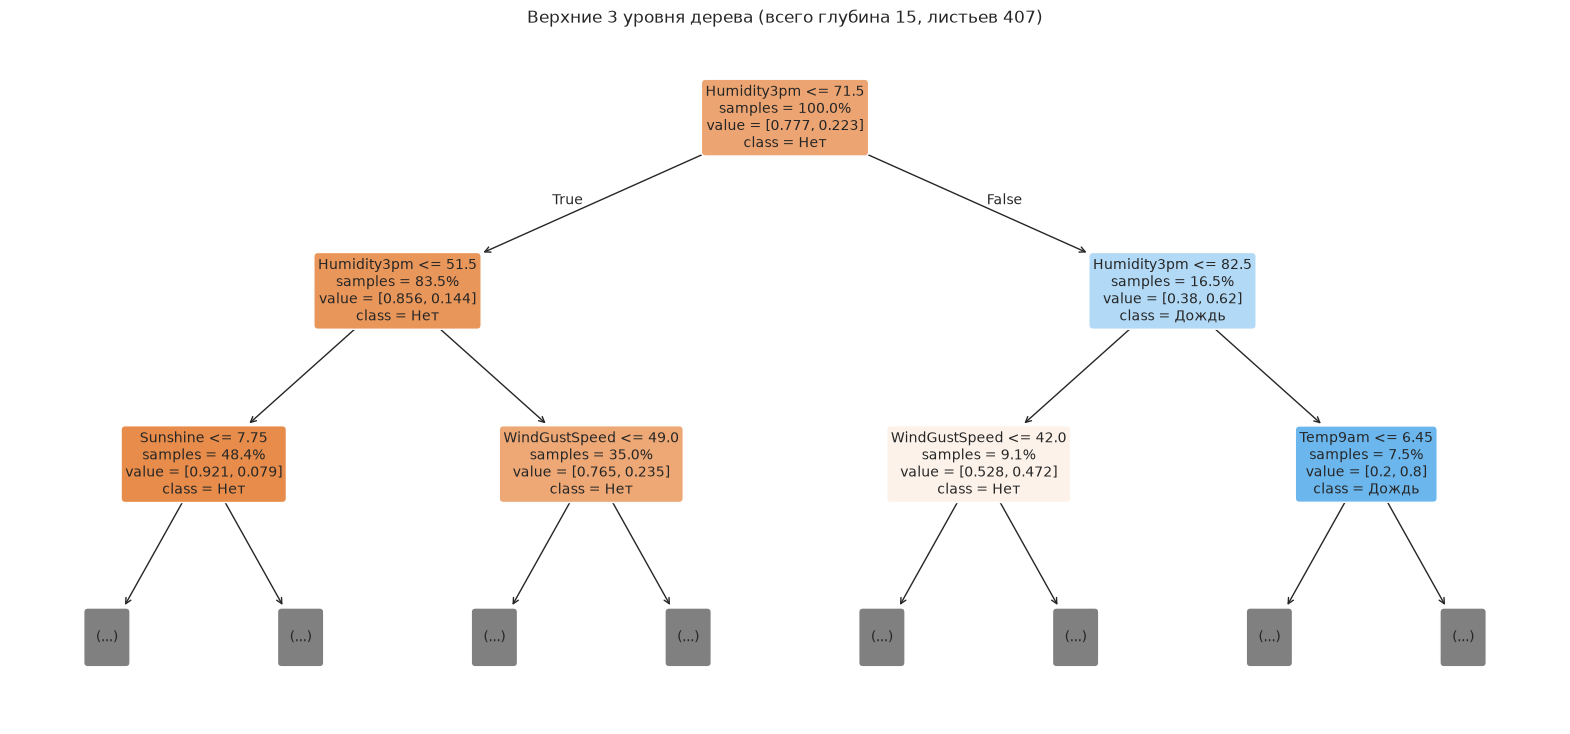

In [19]:
from sklearn.tree import plot_tree

final_tree = final.named_steps["tree"]
feature_names = [n.split("__", 1)[1] for n in final.named_steps["prep"].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(final_tree, max_depth=2, feature_names=feature_names, class_names=["Нет", "Дождь"],
          filled=True, impurity=False, proportion=True, rounded=True, fontsize=10, ax=ax)
ax.set_title(f"Верхние 3 уровня дерева (всего глубина {final_tree.get_depth()}, "
             f"листьев {final_tree.get_n_leaves()})")
plt.show()

Важность признаков — доля суммарного уменьшения Gini, которую дал признак во всех разбиениях. Это impurity-based оценка: она завышает непрерывные признаки с множеством возможных порогов, поэтому это ориентир, а не строгая мера.

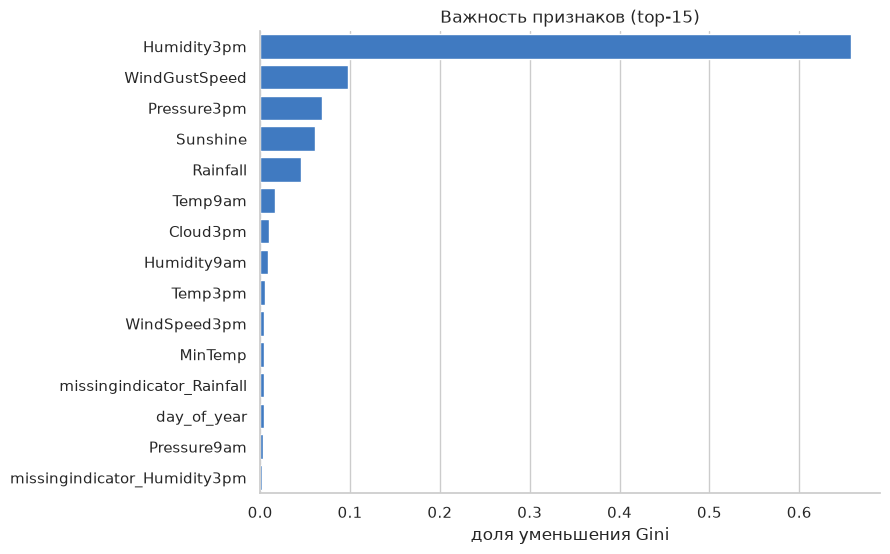

In [20]:
importance = pd.Series(final_tree.feature_importances_, index=feature_names).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importance.values, y=importance.index, color=BLUE, ax=ax)
ax.set(title="Важность признаков (top-15)", xlabel="доля уменьшения Gini", ylabel="")
plt.show()